# Bogus Basin Snow Depth

In [1]:


import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import os
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pathlib import Path
import sys
from data_registry import datasets
from scipy.ndimage import uniform_filter1d
import statsmodels.formula.api as smf
import statsmodels.api as sm
import scipy.stats as stats
from scipy.interpolate import interp1d
from utils import mainutil
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.gam.api import GLMGam
from statsmodels.gam.api import BSplines
from statsmodels.tsa.stattools import adfuller, kpss
import warnings
warnings.filterwarnings("ignore")
# os.getcwd()
# os.chdir(r"C:\Users\ryanc\repo\Time-Series-Analysis-Project")
    

*Utility functions*


In [2]:
def evaluate_performance(true, pred, model_name="Model"):
    mspe = mean_squared_error(true, pred)
    mae = mean_absolute_error(true, pred)
    mape = np.mean(np.abs((true - pred) / (true + 1e-6)))
    pm = (np.sum((true- pred) ** 2) / np.sum((true- np.mean(true)) ** 2))

    print(f"=== {model_name} Performance ===")
    print(f"MSPE: {mspe:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"MAPE: {mape:.4f}")
    print(f"PM:   {pm:.4f}")
    print("-" * 40)

def to_ts(data, dates=None):
    data = data.copy()
    aDict = {'ts': np.array(data)}
    aRange = np.arange(len(data))
    aDict['pts'] = (aRange - np.min(aRange)) / np.max(aRange)
    if dates is not None:
        indexDates = pd.to_datetime(dates, errors='coerce')
    elif isinstance(data, pd.Series) and isinstance(data.index, pd.DatetimeIndex):
        indexDates = data.index
    else:
        indexDates = aRange
    return pd.DataFrame(aDict, index=indexDates).dropna()

## Plot and Exploratory Analysis

*Read data*

In [3]:

snow_data = pd.read_csv('BogusSnowDaily.csv')
snow_data.columns = (['Date', 'Depth'])

snow_data['Date'] = pd.to_datetime(snow_data['Date'])
snow_data.set_index('Date',drop=True, inplace=True)

snow_daily = to_ts(snow_data['Depth'], snow_data.index)


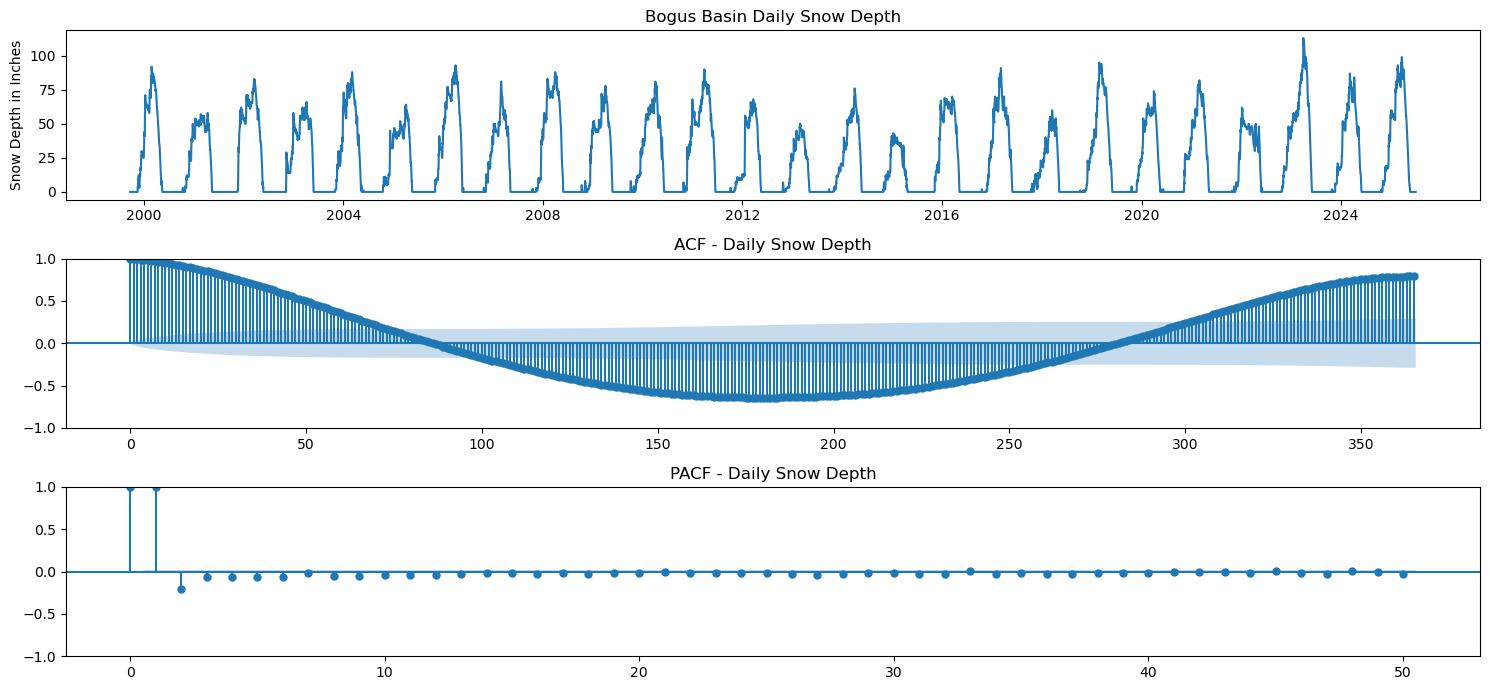

In [4]:
fig, axs = plt.subplots(3,1 ,figsize=(15,7))
axs[0].plot(snow_daily['ts'])
axs[0].set_title('Bogus Basin Daily Snow Depth')
axs[0].set_ylabel("Snow Depth in Inches")
plot_acf(snow_daily['ts'], lags = 365, ax = axs[1], title = 'ACF - Daily Snow Depth');
plot_pacf(snow_daily['ts'], lags = 50, ax = axs[2], title = "PACF - Daily Snow Depth");

# axs[1].plot(snow_monthly['ts'], marker = '.', markersize = 5  )
# axs[1].set_title('Bogus Basin Monthly Average Snow Depth')
# axs[1].set_ylabel("Snow Depth in Inches")
fig.tight_layout()
fig.show()

The daily snow data exhibits a strong seasonal pattern with no clear discernable trend. A key feature of this data is the large periods of time with zero values during the warmer months.  While one approach could be to remove all the zero values, they are a key data point, as forecasting when snow begins and ends is a key part of this analysis.  Close attention will be paid to how successful the models are in capturing these zero points. 

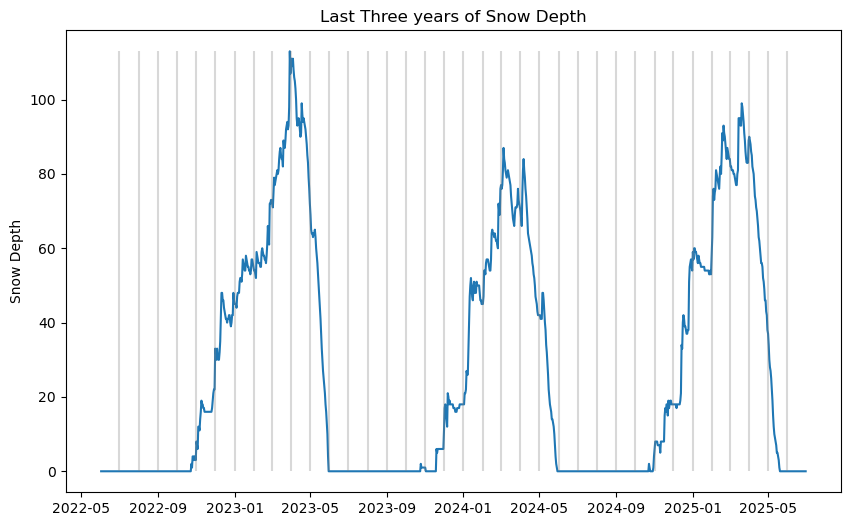

In [5]:
last_3_years = snow_daily[snow_daily.index > '2022-06-01']
loc = mdates.MonthLocator(bymonthday=1)
month_starts = loc.tick_values(last_3_years.index.min(), last_3_years.index.max())

plt.figure(figsize=(10,6))
plt.plot(last_3_years['ts'])
plt.vlines(month_starts, 0,last_3_years['ts'].max(), alpha = .3, color = 'grey')
plt.title("Last Three years of Snow Depth")
plt.ylabel("Snow Depth")
plt.show()


Focusing in on the last three years of snow data shows interesting patterns in each year.  The warmer months have a snow depth of 0, typically from June to October or November.  Snow depth is dictated by snow storms, which lead to a sharp increase in snow depth.  The sharp increase is followed by a period of no increase or slight decrease, as snow melts. The peak of snow depth is reached around April each year, when warming temperatures lead melting snow and a sharp decrease in snow levels.  

Splitting data into training and testing data sets, with testing set for the last year's worth of data. Adding in categorical viariables at month, week, and day levels for seasonal analysis 

In [6]:
cutoff_date = '06/01/2024'

sd= snow_daily.copy()
sd['ts'] = sd['ts']+1
sd['month'] = sd.index.month
sd['week'] = sd.index.isocalendar().week.astype('int')
sd['day'] = sd.index.dayofyear

sd_train = sd[sd.index<cutoff_date]
sd_test = sd[sd.index>=cutoff_date]

print(sd_train.tail())
print(sd_test.head())


            ts       pts  month  week  day
Date                                      
2024-05-27   5  0.957598      5    22  148
2024-05-28   3  0.957705      5    22  149
2024-05-29   2  0.957811      5    22  150
2024-05-30   1  0.957917      5    22  151
2024-05-31   1  0.958023      5    22  152
            ts       pts  month  week  day
Date                                      
2024-06-01   1  0.958130      6    22  153
2024-06-02   1  0.958236      6    22  154
2024-06-03   1  0.958342      6    23  155
2024-06-04   1  0.958448      6    23  156
2024-06-05   1  0.958555      6    23  157


# Decomposition Modeling



## Trend Estimation Using Moving Average, Local Polynomial, and Splines

In [7]:
#Moving Average Trend
mavModel = uniform_filter1d(sd_train['ts'], size=len(sd_train['ts'])//2)
mavModel
mav_data = pd.Series(mavModel, index=sd_train.index)


#Lowess Trend
localPolyModel = sm.nonparametric.lowess(endog=sd_train['ts'], exog=sd_train['pts'], is_sorted=True, frac=0.5)

## extrapolate local polynomial and Moving Average onto test data
f = interp1d(localPolyModel[:,0], localPolyModel[:,1], bounds_error=False, fill_value="extrapolate")
sd_test['LocalPoly_Trend'] = f(sd_test['pts'])
sd_test['MovingAvg_Trend'] = mav_data[-1]

# Splines Trend
gamModel = GLMGam.from_formula(
    formula='ts ~ 1', data=sd_train, alpha=100,
    family=sm.families.Gaussian(),
    smoother=BSplines(sd_train['pts'], df=30, degree=3)).fit()



localPolyData = pd.Series(localPolyModel[:,1], index=sd_train.index)
sd_train['MovingAvg_Trend'] = mav_data
sd_train['LocalPoly_Trend'] = localPolyData
sd_train['spline'] = gamModel.fittedvalues


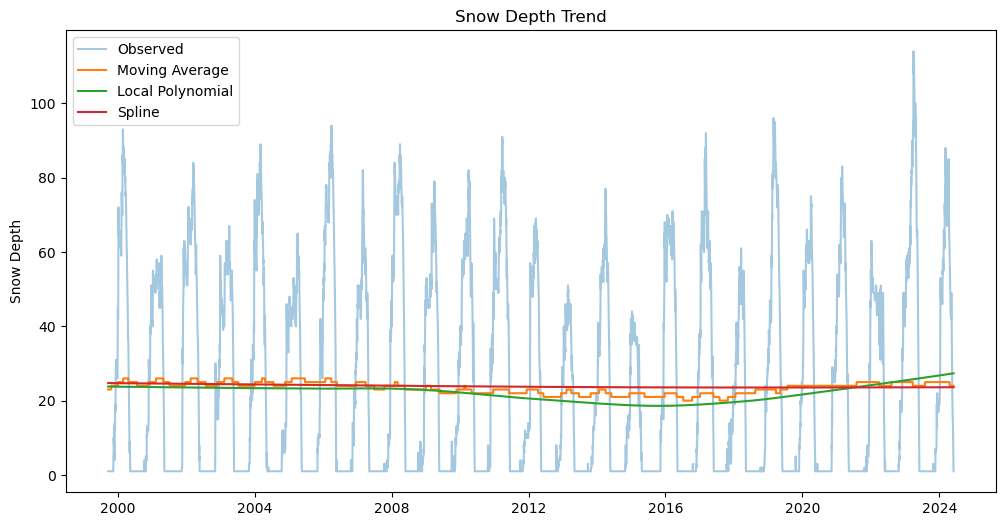

In [8]:
plt.figure(figsize = (12,6))
plt.plot(sd_train['ts'], alpha =.4)
plt.plot(sd_train['MovingAvg_Trend'])

plt.plot(sd_train['LocalPoly_Trend'])
plt.plot(sd_train['spline'])

plt.legend(['Observed', 'Moving Average', 'Local Polynomial', 'Spline'])
plt.ylabel('Snow Depth')
plt.title("Snow Depth Trend")
plt.show()

To determine any trend in the data, a moving average, local polynomial using LOWESS, and splines regression were all used.  The moving average appears to capture some of the seasonal pattern in the data.  The splines regression shows no discernable trend, while the local polynomial shows a slight decrease from 2012 to 2016, and then an increase from 2016 till 2024. As the local polynomial appears to best capture the long term fluctuations in the daily snow levels, it will be used in further decomposition models. 

## Seaonality Estimation

In [ ]:
## Function to generate harmonic series for seaonality 
def generate_fourier_terms(time, period, K):

    fourier_terms = {}
    for k in range(1, K + 1):
        fourier_terms[f'sin_{k}'] = np.sin(2 * np.pi * k * time / period)
        fourier_terms[f'cos_{k}'] = np.cos(2 * np.pi * k * time / period)
    return pd.DataFrame(fourier_terms)


f_train = generate_fourier_terms(sd_train.index.dayofyear, 365, 3)
f_train =f_train.set_index(sd_train.index)
f_train


,sin_1,cos_1,sin_2,cos_2,sin_3,cos_3
Date,,,,,,
1999-09-23,-0.991114,-0.133015,0.263665,-0.964614,0.920971,0.389630
1999-09-24,-0.993257,-0.115935,0.230306,-0.973118,0.939856,0.341571
1999-09-25,-0.995105,-0.098820,0.196673,-0.980469,0.956235,0.292600
1999-09-26,-0.996659,-0.081676,0.162807,-0.986658,0.970064,0.242850
1999-09-27,-0.997917,-0.064508,0.128748,-0.991677,0.981306,0.192452
...,...,...,...,...,...,...
2024-05-27,0.559589,-0.828770,-0.927542,0.373720,0.977848,0.209315
2024-05-28,0.545240,-0.838280,-0.914128,0.405426,0.987349,0.158559
2024-05-29,0.530730,-0.847541,-0.899631,0.436651,0.994218,0.107381


In [11]:
sd_train =sd_train.join(f_train)


In [101]:


sd_train['ts_sqrt'] = np.sqrt(sd_train['ts'])
sd_train['ts_log'] = np.log(sd_train['ts'])


seasonalmodel_LocalPoly_trend_Harmonic2 = smf.ols(formula = 'ts~ sin_1 + cos_1+ +cos_2 +sin_2+ LocalPoly_Trend', data = sd_train).fit()
seasonalmodel_LocalPoly_trend_Harmonic3 = smf.ols(formula = 'ts~ sin_1 + cos_1+ +cos_2 +sin_2+ +cos_3 + sin_3+ LocalPoly_Trend', data = sd_train).fit()
seasonal_model_WeeklyAnova_w_Poly = smf.ols(formula = 'ts~C(week)+LocalPoly_Trend', data = sd_train).fit()
#seasonal_model_MonthlyAnova_w_Poly = smf.ols(formula = 'ts~C(month)+MovingAvg_Trend', data = sd_train).fit()
#seasonal_monthlyANOVA_Harmonics3 = smf.ols(formula = 'ts~C(month)+LocalPoly_Trend + sin_1 + cos_1+ +cos_2 +sin_2+ +cos_3 + sin_3+ LocalPoly_Trend', data = sd_train).fit()
log_harmonic_2 = smf.ols(formula = 'ts_log~ sin_1 + cos_1+ +cos_2 +sin_2+ LocalPoly_Trend', data = sd_train).fit()
log_harmonic_3 = smf.ols(formula = 'ts_log~ sin_1 + cos_1+ +cos_2 +sin_2+ +cos_3 + sin_3+ LocalPoly_Trend', data = sd_train).fit()
log__weekly_anova =  smf.ols(formula = 'ts_log~C(week)+LocalPoly_Trend', data = sd_train).fit()

## Analyzing Fit

In [21]:
def analysis_plots(observed, fitted, residuals,  model_name):
    fig, axs = plt.subplots(4,1, figsize =(12,14) )
    axs[0].plot(observed, color = 'grey', alpha = .7)
    axs[0].plot(fitted, color = 'green')
    axs[0].set_ylabel("Snow Depth")
    axs[0].legend(['Observed', model_name], fontsize = 8)
    axs[0].set_title(model_name, size=10)

    axs[1].plot(residuals)
    axs[1].set_ylabel("Residuals")
    axs[1].set_title(f"{model_name} residuals", size = 10)

    plot_acf(residuals, ax=axs[2] ,lags= 350)
    plot_pacf(residuals, ax=axs[3], lags = 350 )
    axs[2].set_title(f"ACF: { model_name}", size = 9)
    axs[3].set_title(f"PACF: { model_name}", size = 9)
    df_test = adfuller(residuals, regression = 'c')
    print(f"ADF: Test statistic = {df_test[0]:.4f}, p-value = {df_test[1]:.4f}")
    statistic, p_value, n_lags, critical_values = kpss(residuals, regression='c')
    print(f"Kpss: Test statistic = {statistic}, p-value = {p_value}")
    

### Harmonic Models

ADF: Test statistic = -10.5245, p-value = 0.0000
Kpss: Test statistic = 0.06310523325347159, p-value = 0.1


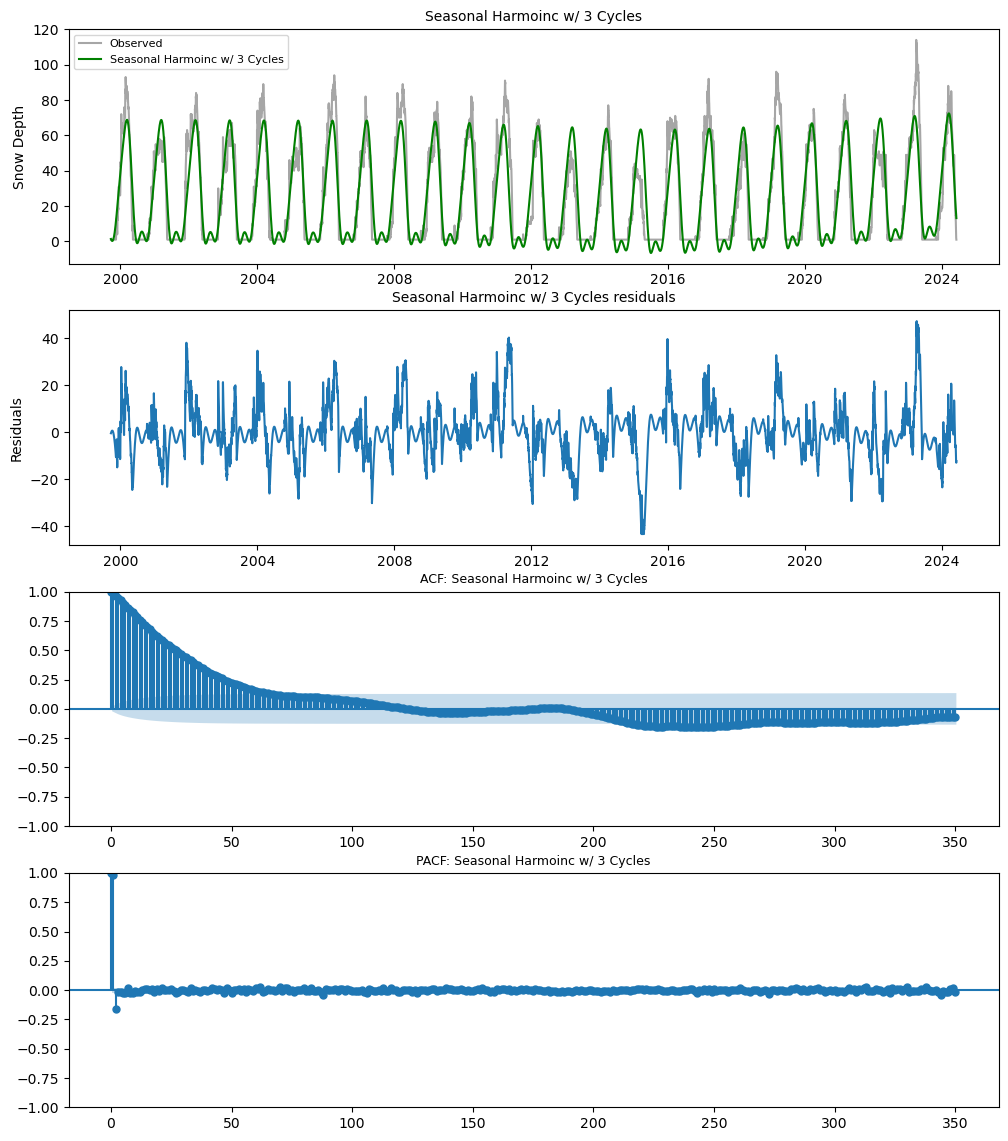

In [22]:
analysis_plots(sd_train['ts'], seasonalmodel_LocalPoly_trend_Harmonic3.fittedvalues, seasonalmodel_LocalPoly_trend_Harmonic3.resid, "Seasonal Harmoinc w/ 3 Cycles")

ADF: Test statistic = -14.6329, p-value = 0.0000
Kpss: Test statistic = 0.07431314716855111, p-value = 0.1


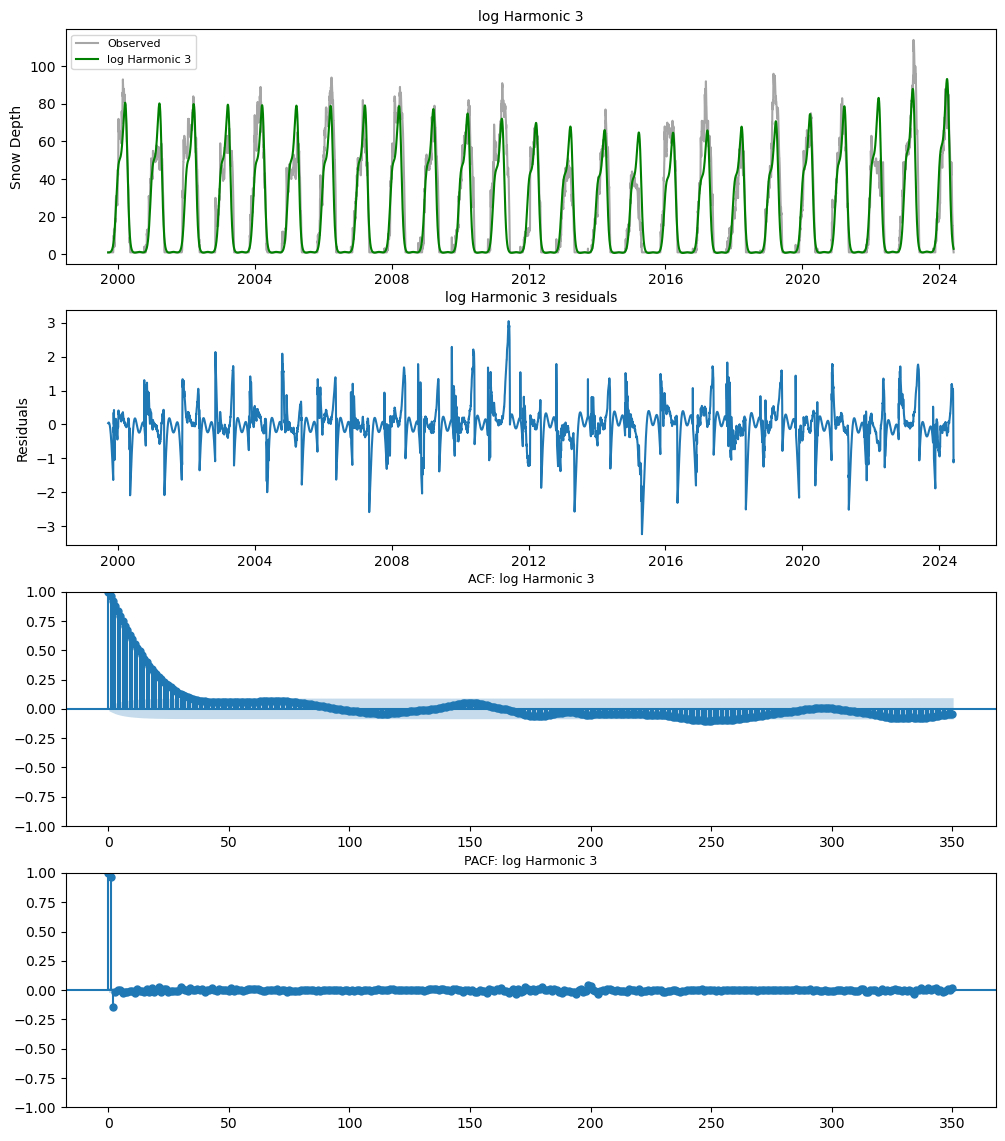

In [137]:
analysis_plots(sd_train['ts'], np.exp(log_harmonic_3.fittedvalues), log_harmonic_3.resid, "log Harmonic 3")


ADF: Test statistic = -10.6852, p-value = 0.0000
Kpss: Test statistic = 0.058640954502900314, p-value = 0.1


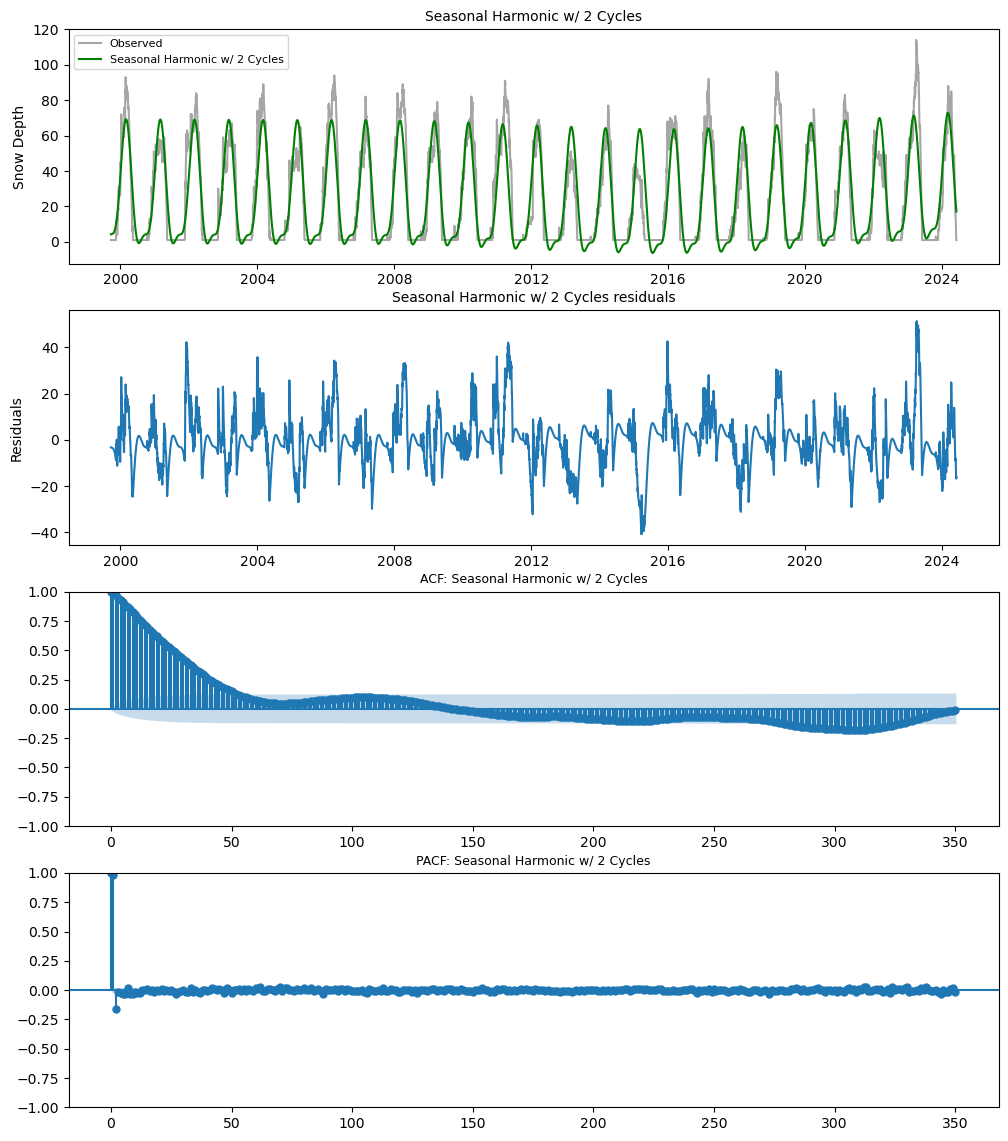

In [72]:
analysis_plots(sd_train['ts'], seasonalmodel_LocalPoly_trend_Harmonic2.fittedvalues, seasonalmodel_LocalPoly_trend_Harmonic2.resid, "Seasonal Harmonic w/ 2 Cycles")


### ANOVA

ADF: Test statistic = -9.1336, p-value = 0.0000
Kpss: Test statistic = 0.06342396047439114, p-value = 0.1


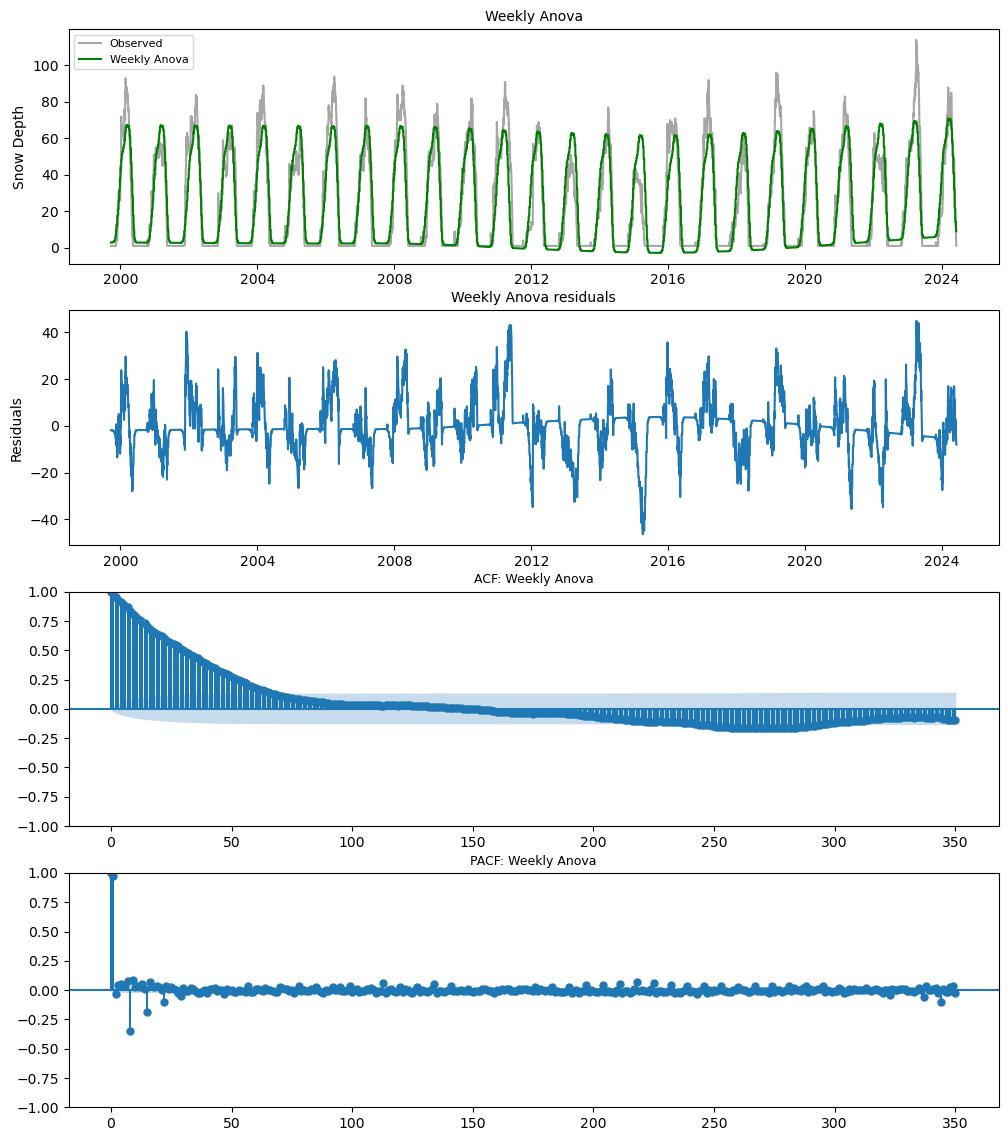

In [24]:
analysis_plots(sd_train['ts'], seasonal_model_WeeklyAnova_w_Poly.fittedvalues, seasonal_model_WeeklyAnova_w_Poly.resid, "Weekly Anova")


ADF: Test statistic = -9.7688, p-value = 0.0000
Kpss: Test statistic = 0.07673157101005944, p-value = 0.1


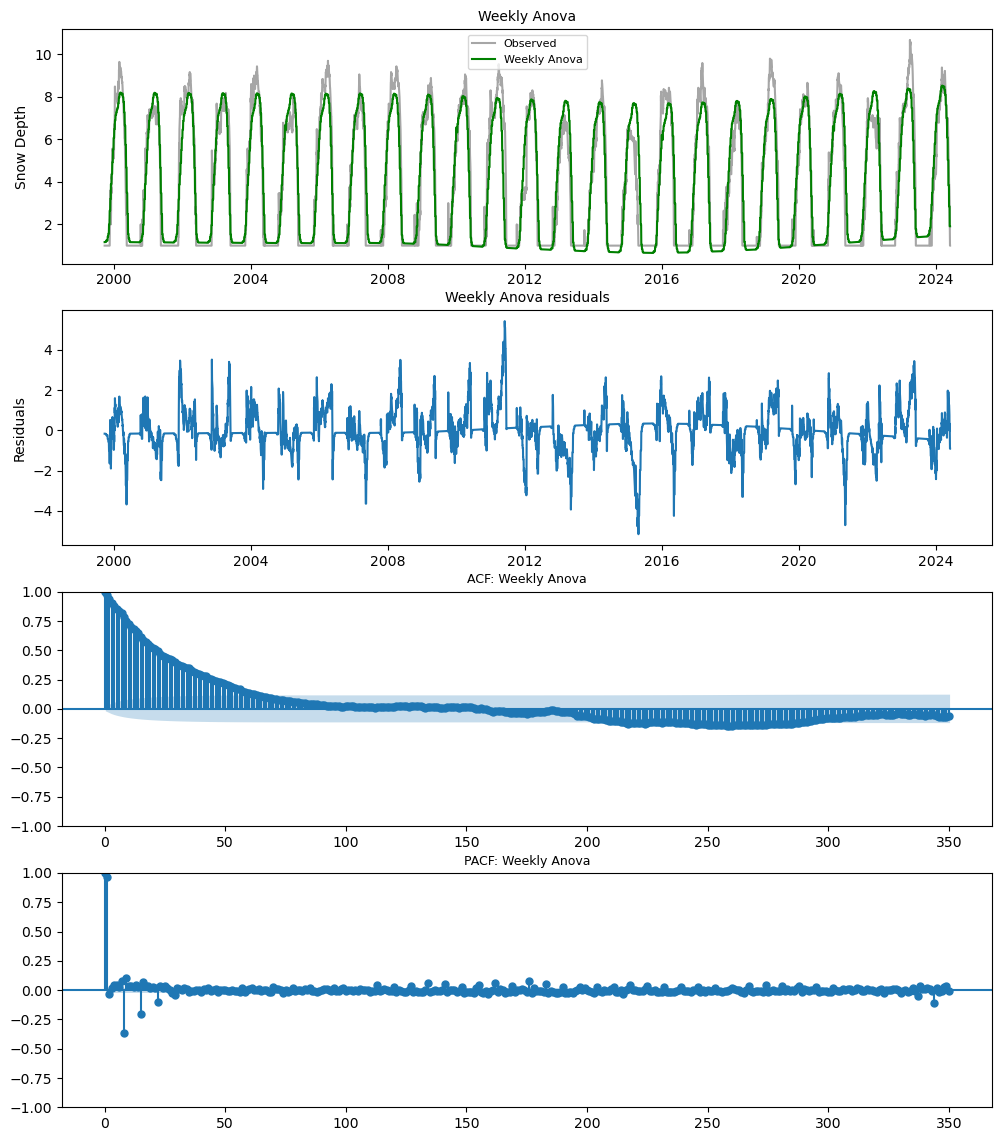

In [25]:
analysis_plots(sd_train['ts_sqrt'], sqrt__weekly_anova.fittedvalues, sqrt__weekly_anova.resid, "Weekly Anova")

## Forcasting

Prepping test data for forecasting

In [36]:
f_test = generate_fourier_terms(sd_test.index.dayofyear, 365, 3)
f_test = f_test.set_index(sd_test.index)
sd_test = sd_test.join(f_test)

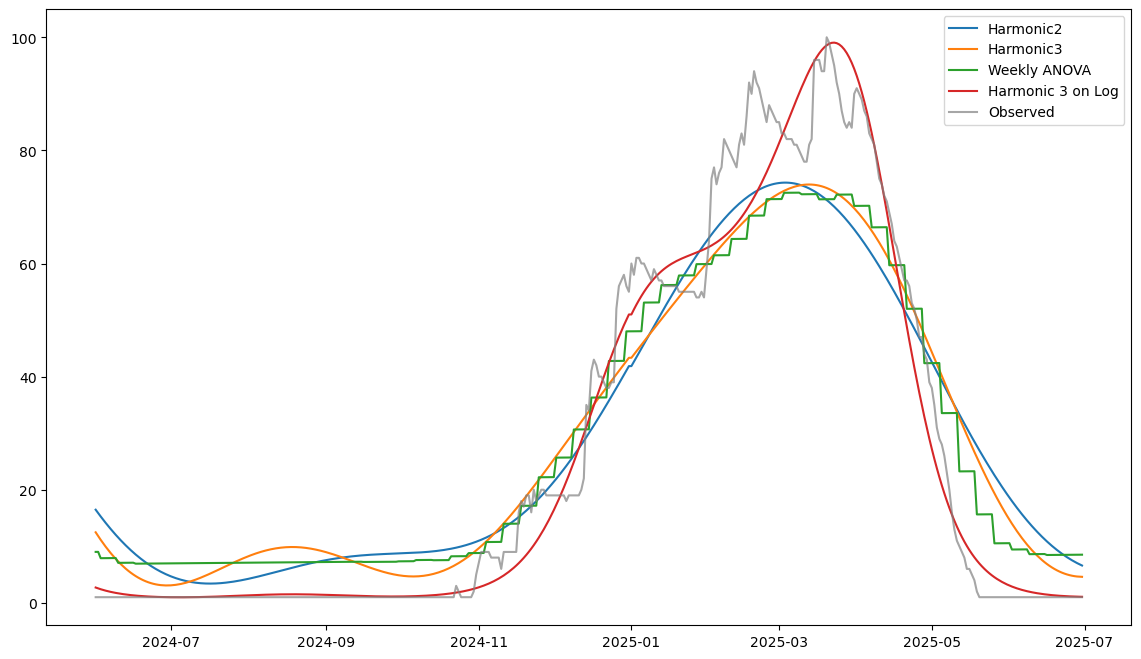

In [108]:

sd_test['ts_sqrt'] = np.sqrt(sd_test['ts'])
sd_test['ts_log'] = np.log(sd_test['ts']+1)



plt.figure( figsize = (14,8))
#plt.plot(seasonalmodel_LocalPoly_trend_myf.predict(exog = sd_test)**2)
plt.plot(seasonalmodel_LocalPoly_trend_Harmonic2.predict(exog = sd_test))
plt.plot(seasonalmodel_LocalPoly_trend_Harmonic3.predict(exog = sd_test))
#plt.plot(seasonalmodel_no_trend.predict(exog=sd_test)**2)
# plt.plot(seasonalmodel_LocalPoly_trend.predict(exog=sd_test)**2)
# plt.plot(seasonalmodel_MA_trend.predict(exog=sd_test)**2)
plt.plot(seasonal_model_WeeklyAnova_w_Poly.predict(exog=sd_test))
plt.plot(np.exp(log_harmonic_3.predict(exog=sd_test)))
# plt.plot(seasonal_model_DailyAnova_w_Poly.predict(exog=sd_test)**2)
plt.plot(sd_test['ts'], color = 'grey', alpha = .7)
plt.legend(['Harmonic2', 'Harmonic3', "Weekly ANOVA", 'Harmonic 3 on Log','Observed'])

All additive models follow the basic seasonal pattern of the last year of the data.  However, they fail to capture the nuance of the data, not following any increase after snow storms. All fail to effectivly capture the zero snow depth that occurs between late spring thru fall

In [109]:
evaluate_performance(sd_test['ts'],seasonalmodel_LocalPoly_trend_Harmonic2.predict(exog = sd_test), 'local poly harmonic 2' )
evaluate_performance(sd_test['ts'],seasonalmodel_LocalPoly_trend_Harmonic3.predict(exog = sd_test), 'local poly harmonic 3' )
evaluate_performance(sd_test['ts'],seasonal_model_WeeklyAnova_w_Poly.predict(exog = sd_test), 'weekly anova' )
evaluate_performance(sd_test['ts'], np.exp(log_harmonic_3.predict(exog=sd_test)), "log Harmonic")  

=== local poly harmonic 2 Performance ===
MSPE: 126.1570
MAE:  9.1929
MAPE: 4.0960
PM:   0.1152
----------------------------------------
=== local poly harmonic 3 Performance ===
MSPE: 109.1144
MAE:  8.4820
MAPE: 3.4732
PM:   0.0996
----------------------------------------
=== weekly anova Performance ===
MSPE: 95.0949
MAE:  8.1642
MAPE: 3.5230
PM:   0.0868
----------------------------------------
=== log Harmonic Performance ===
MSPE: 32.0314
MAE:  3.5622
MAPE: 0.4069
PM:   0.0292
----------------------------------------


## Facebook Prophet

Facebook prophet is a additive time-series forecasting model.  Its output will be compared to the additve modled developed above.

In [ ]:
## Shaping data for prophet
prof_train = pd.DataFrame( sd_train.index, sd_train.copy()['ts_log']).reset_index()
prof_train.rename(columns={'ts_log':'y', 'Date':'ds'}, inplace=True)
prof_train.head()

prof_test = pd.DataFrame( sd_test.index, sd_test.copy()['ts_log']).reset_index()
prof_test.rename(columns={'ts_log':'y', 'Date':'ds'}, inplace=True)
prof_test.head()

,y,ds
0,0.693147,2024-06-01
1,0.693147,2024-06-02
2,0.693147,2024-06-03
3,0.693147,2024-06-04
4,0.693147,2024-06-05


11:01:34 - cmdstanpy - INFO - Chain [1] start processing
11:01:36 - cmdstanpy - INFO - Chain [1] done processing


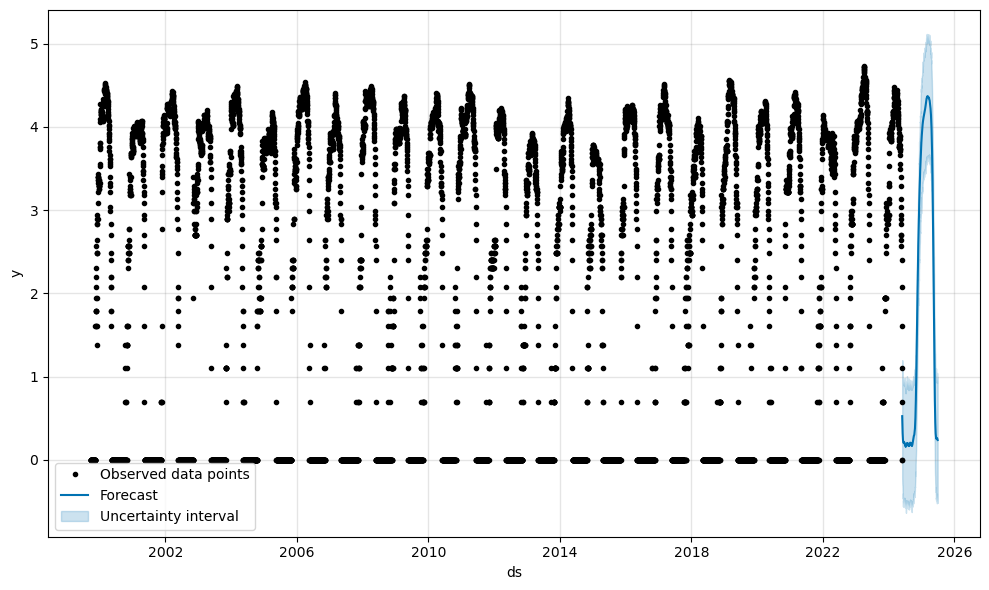

In [ ]:
m = Prophet()
m.fit(prof_train)
prof_forecast = m.predict(prof_test)
plot = m.plot(prof_forecast, include_legend=True, )
plot.show()

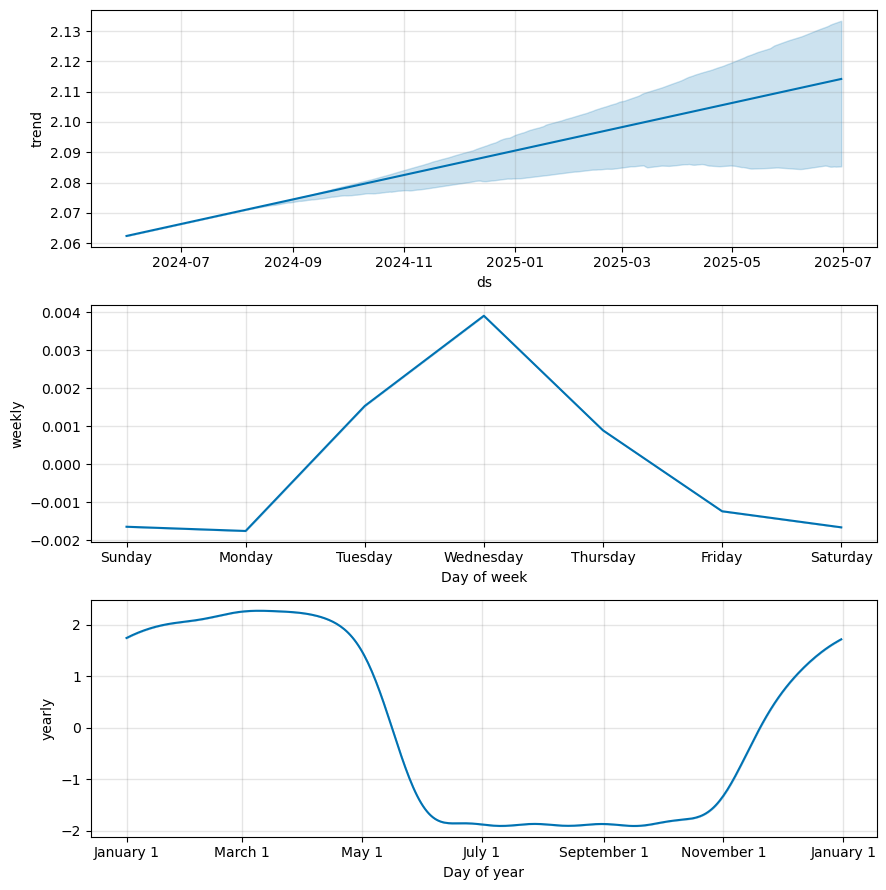

In [ ]:
m.plot_components(prof_forecast);

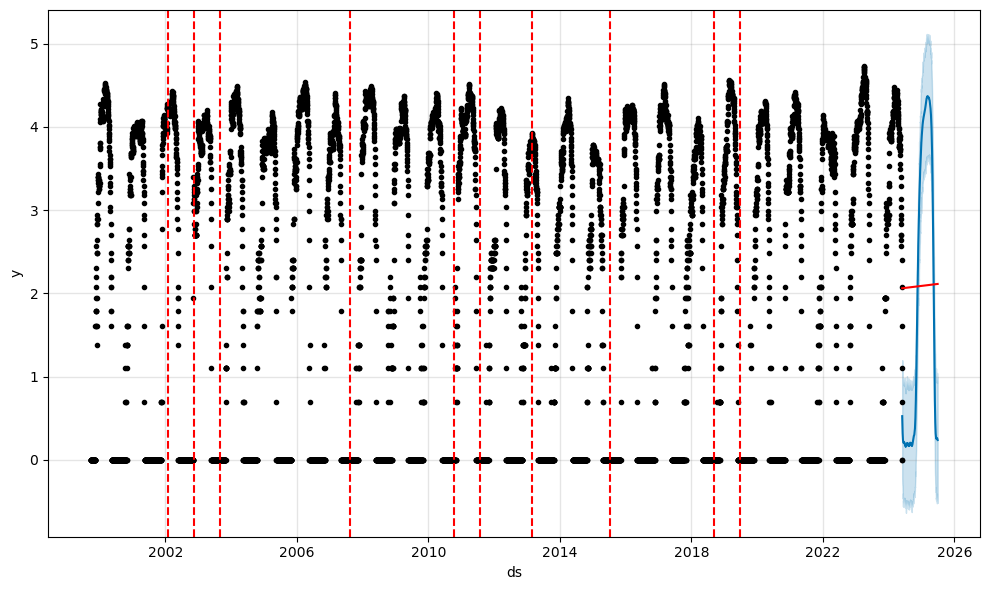

In [ ]:
from prophet.plot import add_changepoints_to_plot
fig = m.plot(prof_forecast)
a = add_changepoints_to_plot(fig.gca(),
                             m, prof_forecast)

In [138]:
prof_forecast_vals = np.exp(prof_forecast['yhat'])
prof_forecast_vals.index = prof_forecast['ds']

Comparing the prophet forecast to the log_harmonic_3 forecast

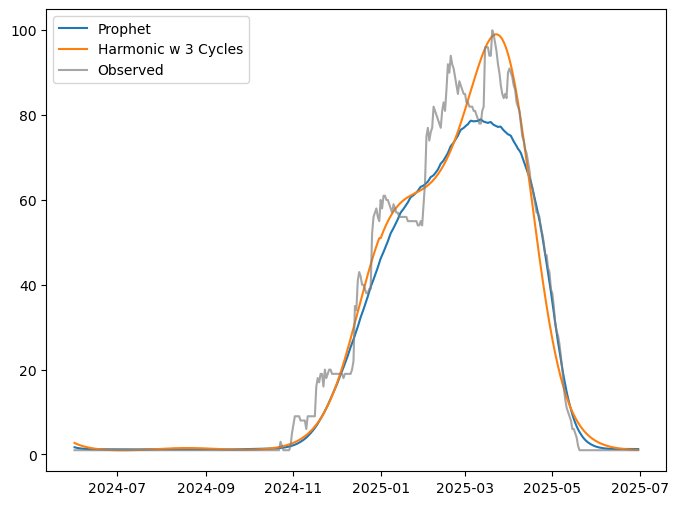

In [144]:
plt.figure(figsize = (8,6))
plt.plot(prof_forecast_vals)
plt.plot(np.exp(log_harmonic_3.predict(exog=sd_test)))
plt.plot(sd_test['ts'], color = 'grey', alpha = .7)
plt.legend(['Prophet', 'Harmonic w 3 Cycles', 'Observed'])

In [140]:
evaluate_performance(sd_test['ts'],prof_forecast_vals, 'profet')

=== profet Performance ===
MSPE: 39.2645
MAE:  3.7209
MAPE: 0.2949
PM:   0.0358
----------------------------------------


# ARIMA with Fourier Series

In [64]:
sd_train['ts_log'] = np.log(sd_train['ts'])

In [45]:
ArimaHarmonics = generate_fourier_terms(sd_train.index.dayofyear, 365, 2)
ArimaHarmonics.index = sd_train.index
ArimaHarmonics

,sin_1,cos_1,sin_2,cos_2
Date,,,,
1999-09-23,-0.991114,-0.133015,0.263665,-0.964614
1999-09-24,-0.993257,-0.115935,0.230306,-0.973118
1999-09-25,-0.995105,-0.098820,0.196673,-0.980469
1999-09-26,-0.996659,-0.081676,0.162807,-0.986658
1999-09-27,-0.997917,-0.064508,0.128748,-0.991677
...,...,...,...,...
2024-05-27,0.559589,-0.828770,-0.927542,0.373720
2024-05-28,0.545240,-0.838280,-0.914128,0.405426
2024-05-29,0.530730,-0.847541,-0.899631,0.436651


Arima fit on snow depth

In [46]:
maxp=7
maxd=2
maxq=7

best_bic = np.inf
selected_orders = (0,0,0)

for p in range(maxp+1):
    for q in range(maxq+1):
        for d in range(maxd):
            orders = (p,d,q)
            model = sm.tsa.statespace.SARIMAX(
                sd_train['ts'], 
                exog = ArimaHarmonics,
                order=orders                   
                        )

    results = model.fit()
    bic = results.bic
    if bic < best_bic:
        best_bic = bic
        selected_orders = orders

print(selected_orders, bic)

(0, 1, 7) 36379.94686835286


In [48]:
arima_fourier_model =sm.tsa.statespace.SARIMAX(
                sd_train['ts'], 
                exog = ArimaHarmonics,
                order=selected_orders ).fit()
print(arima_fourier_model.summary())


                               SARIMAX Results                                
Dep. Variable:                     ts   No. Observations:                 9016
Model:               SARIMAX(0, 1, 7)   Log Likelihood              -18109.696
Date:                Tue, 28 Apr 2026   AIC                          36243.391
Time:                        09:05:41   BIC                          36328.671
Sample:                             0   HQIC                         36272.408
                               - 9016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sin_1         28.0044      3.054      9.171      0.000      22.020      33.989
cos_1         17.9378      2.805      6.395      0.000      12.440      23.436
sin_2          8.4138      1.415      5.944      0.0

Arima fit on Log of snow depth

In [65]:
maxp=7
maxd=2
maxq=7

best_bic = np.inf
selected_orders = (0,0,0)

for p in range(maxp+1):
    for q in range(maxq+1):
        for d in range(maxd):
            orders = (p,d,q)
            model = sm.tsa.statespace.SARIMAX(
                sd_train['ts_log'], 
                exog = ArimaHarmonics,
                order=orders                   
                        )

    results = model.fit()
    bic = results.bic
    if bic < best_bic:
        best_bic = bic
        selected_orders = orders

print(selected_orders, bic)

(4, 1, 7) -7650.69885441663


In [66]:
log_arima_fourier_model =sm.tsa.statespace.SARIMAX(
                sd_train['ts_log'], 
                exog = ArimaHarmonics,
                order=selected_orders ).fit()
print(log_arima_fourier_model.summary())


                               SARIMAX Results                                
Dep. Variable:                 ts_log   No. Observations:                 9016
Model:               SARIMAX(4, 1, 7)   Log Likelihood                3983.368
Date:                Tue, 28 Apr 2026   AIC                          -7934.737
Time:                        09:19:21   BIC                          -7821.031
Sample:                             0   HQIC                         -7896.049
                               - 9016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sin_1          1.8109      0.188      9.620      0.000       1.442       2.180
cos_1          1.5814      0.097     16.386      0.000       1.392       1.771
sin_2          0.1955      0.085      2.295      0.0

ADF: Test statistic = -33.5274, p-value = 0.0000
Kpss: Test statistic = 0.04906368147065379, p-value = 0.1


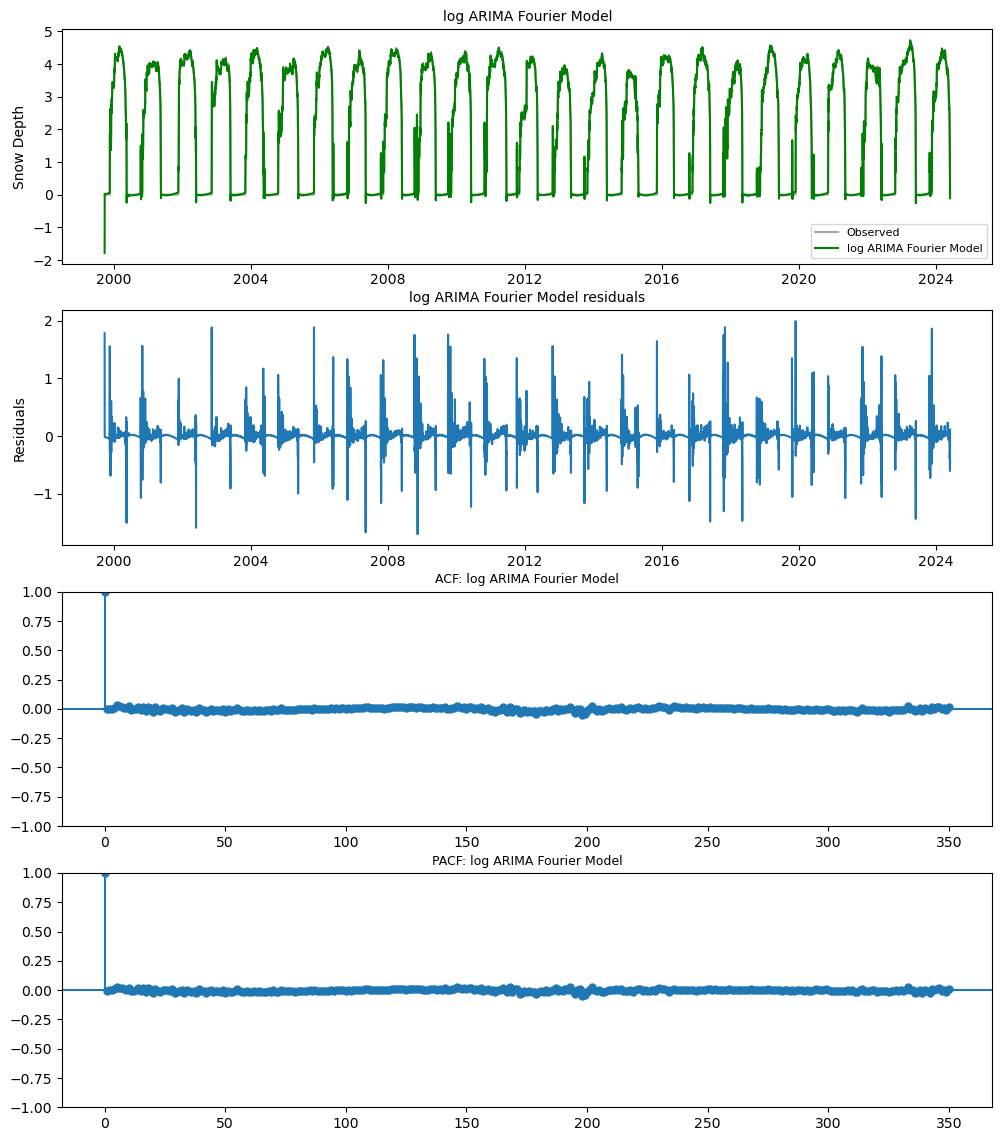

In [68]:
analysis_plots(sd_train['ts_log'], log_arima_fourier_model.fittedvalues, log_arima_fourier_model.resid, "log ARIMA Fourier Model" )

ADF: Test statistic = -95.7201, p-value = 0.0000
Kpss: Test statistic = 0.011991707222880678, p-value = 0.1


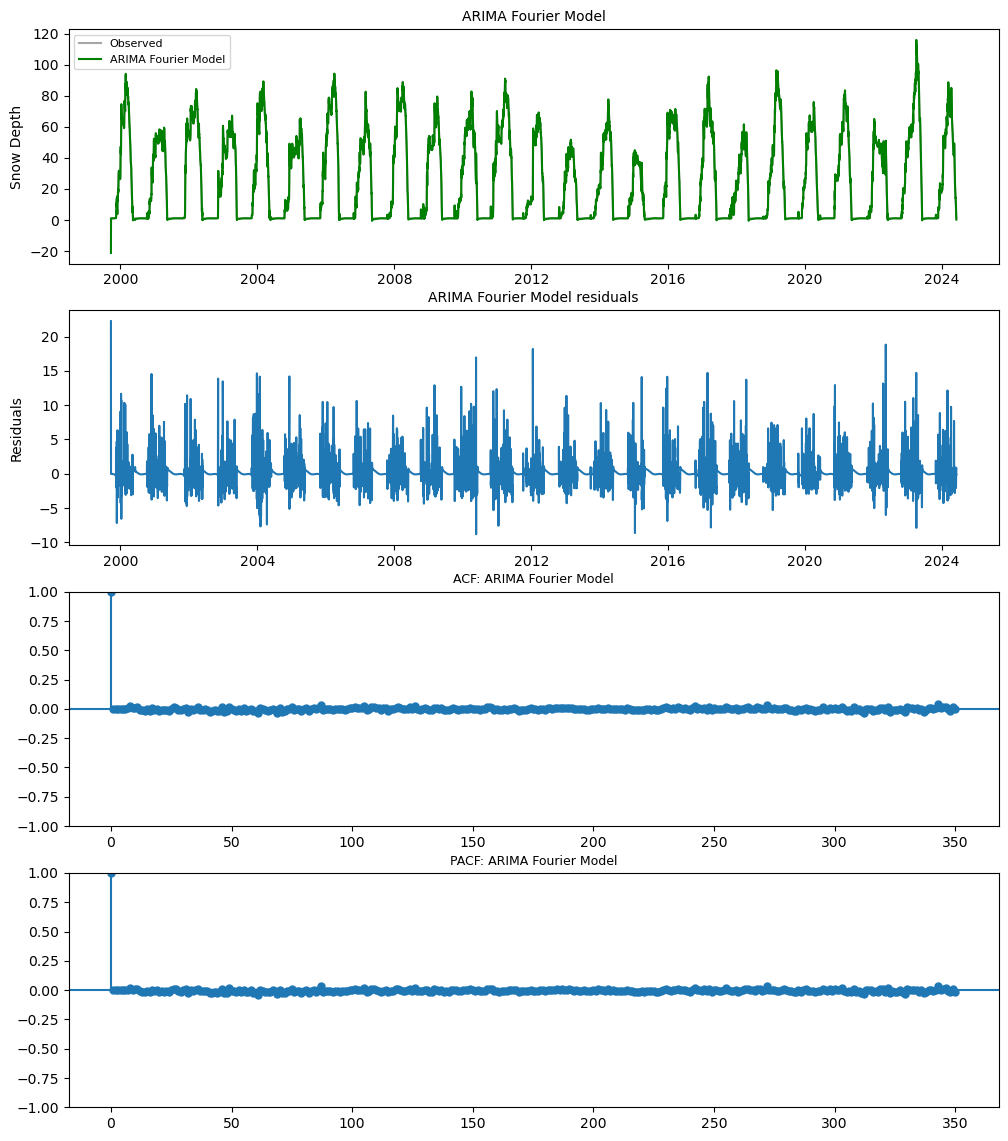

In [49]:
analysis_plots(sd_train['ts'],arima_fourier_model.fittedvalues, arima_fourier_model.resid, "ARIMA Fourier Model" )



In [52]:


forecast_harmonics = generate_fourier_terms(sd_test.index.dayofyear, 365, 2)
forecast_harmonics.index = sd_test.index


In [73]:
arima_yr_forecast = arima_fourier_model.forecast(steps = 395, exog = forecast_harmonics)
log_arima_yr_forecast = log_arima_fourier_model.forecast(steps = 395, exog = forecast_harmonics)

,ts,pts,month,week,day,LocalPoly_Trend,MovingAvg_Trend,sin_1,cos_1,sin_2,cos_2,sin_3,cos_3
Date,,,,,,,,,,,,,
2024-06-01,1,0.958130,6,22,153,27.355991,24,0.486273,-0.873807,-0.849817,0.527078,0.998880,-0.047321
2024-06-02,1,0.958236,6,22,154,27.359818,24,0.471160,-0.882048,-0.831171,0.556017,0.995105,-0.098820
2024-06-03,1,0.958342,6,23,155,27.363645,24,0.455907,-0.890028,-0.811539,0.584298,0.988678,-0.150055
2024-06-04,1,0.958448,6,23,156,27.367473,24,0.440519,-0.897743,-0.790946,0.611886,0.979614,-0.200891
2024-06-05,1,0.958555,6,23,157,27.371300,24,0.425000,-0.905193,-0.769415,0.638749,0.967938,-0.251190
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-26,1,0.999575,6,26,177,28.848601,24,0.094537,-0.995521,-0.188227,0.982126,0.280231,-0.959933
2025-06-27,1,0.999681,6,26,178,28.852428,24,0.077386,-0.997001,-0.154309,0.988023,0.230306,-0.973118
2025-06-28,1,0.999787,6,26,179,28.856255,24,0.060213,-0.998186,-0.120208,0.992749,0.179767,-0.983709


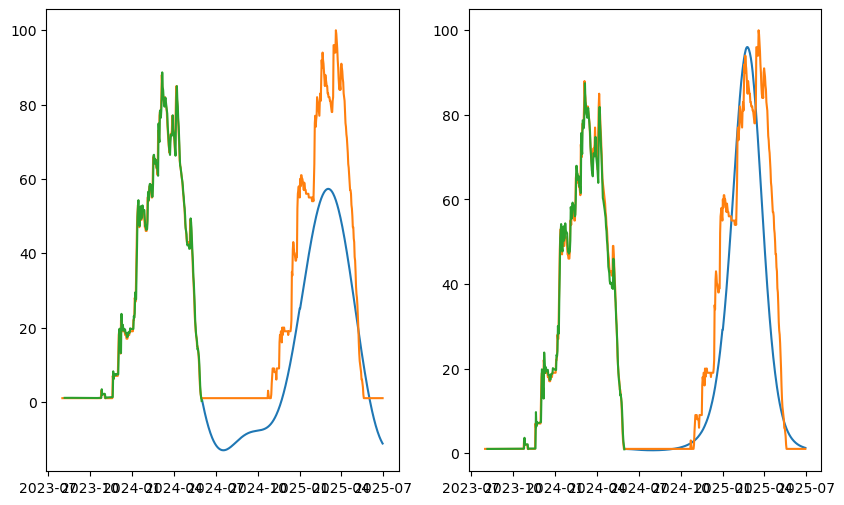

In [80]:
fig, axs = plt.subplots(1,2, figsize = (10,6))
axs[0].plot(sd_test.index, arima_yr_forecast )
axs[0].plot(sd['ts'][-700:])
axs[0].plot(arima_fourier_model.fittedvalues[-300:])

axs[1].plot(sd_test.index, np.exp(log_arima_yr_forecast ))
axs[1].plot(sd['ts'][-700:])
axs[1].plot(np.exp(log_arima_fourier_model.fittedvalues[-300:]))

In [83]:
arima_yr_forecast.index =sd_test.index
arima_yr_forecast
log_arima_yr_forecast.index = sd_test.index

In [56]:
evaluate_performance(sd_test['ts'], arima_yr_forecast, 'Arima' )

=== Arima Performance ===
MSPE: 356.8527
MAE:  15.8783
MAPE: 4.8066
PM:   0.3258
----------------------------------------


In [84]:
evaluate_performance(sd_test['ts'], np.exp(log_arima_yr_forecast), 'ARIMA on Log Transformation')

=== ARIMA on Log Transformation Performance ===
MSPE: 198.0079
MAE:  8.3359
MAPE: 0.5014
PM:   0.1808
----------------------------------------


In [288]:
arima_yr_forecast = mainutil.to_ts(arima_yr_forecast,sd_test.index)

In [290]:
sd_train_roll = sd_train.copy()


Projecting all 395 points into the future leads to a forecast that follows the basic trend of the seaonal pattern observed, but does not leverage the lagged cooeficents fully.  Performing a rolling forecast, much more like in real life leverages these coeefecents much more and leads to much higher accuracy in the forecast. 

In [57]:
forecast_period = 7
number_of_runs = len(sd_test)//forecast_period
results = []
for r in range(1,number_of_runs):
    if r == 1:
        train_rolling = sd_train.copy()
        test_rolling = sd_test.copy()[:forecast_period]
    else: 
        train_rolling = pd.concat([train_rolling, test_rolling])
        test_rolling = sd_test.copy()[forecast_period*(r-1):forecast_period*r]
    f_train = train_rolling[['sin_1', 'cos_1', 'sin_2', 'cos_2']]
    f_test = test_rolling[['sin_1', 'cos_1', 'sin_2', 'cos_2']]
    
    if len(test_rolling) == forecast_period:  forecast_period = forecast_period
    else: forecast_period = len(test_rolling)
    model = sm.tsa.statespace.SARIMAX(
                train_rolling['ts'], 
                exog = f_train,
                order=selected_orders ).fit()
    forecast = model.forecast(steps = forecast_period, exog = f_test)
    forecast = forecast.set_axis(test_rolling.index)
     
    results.append(forecast)
full_forecast = pd.concat(results)




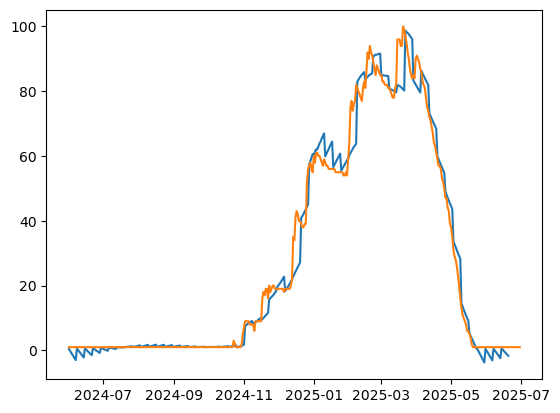

In [58]:
plt.plot(full_forecast)
plt.plot(sd_test['ts'])


In [59]:
evaluate_performance(sd_test['ts'][:385], full_forecast, "arima 7 day rolling")

=== arima 7 day rolling Performance ===
MSPE: 22.4151
MAE:  2.8748
MAPE: 0.4326
PM:   0.0203
----------------------------------------


rolling forcast on log


In [89]:
sd_test['ts_log'] = np.log(sd_test['ts'])

In [98]:
forecast_period = 7
number_of_runs = len(sd_test)//forecast_period
log_results = []
for r in range(1,number_of_runs):
    if r == 1:
        train_rolling = sd_train.copy()
        test_rolling = sd_test.copy()[:forecast_period]
    else: 
        train_rolling = pd.concat([train_rolling, test_rolling])
        test_rolling = sd_test.copy()[forecast_period*(r-1):forecast_period*r]
    f_train = train_rolling[['sin_1', 'cos_1', 'sin_2', 'cos_2']]
    f_test = test_rolling[['sin_1', 'cos_1', 'sin_2', 'cos_2']]
    
    if len(test_rolling) == forecast_period:  forecast_period = forecast_period
    else: forecast_period = len(test_rolling)
    model = sm.tsa.statespace.SARIMAX(
                train_rolling['ts_log'], 
                exog = f_train,
                order=selected_orders ).fit()
    forecast = model.forecast(steps = forecast_period, exog = f_test)
    forecast = forecast.set_axis(test_rolling.index)
     
    log_results.append(forecast)
log_full_forecast = pd.concat(log_results)

In [99]:
log_full_forecast = pd.concat(log_results)

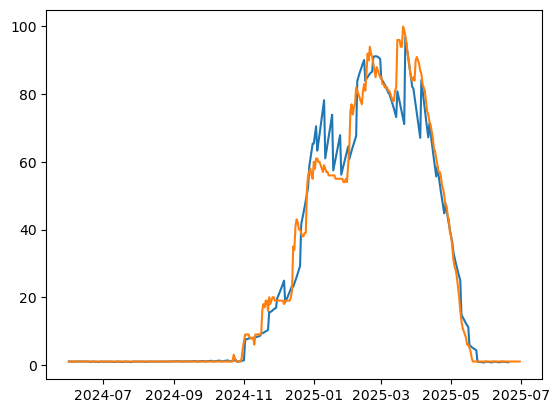

In [100]:
plt.plot(np.exp(log_full_forecast))
plt.plot(sd_test['ts'])

In [97]:
evaluate_performance(sd_test['ts'][:385], np.exp(log_full_forecast), 'log arima rolling')

=== log arima rolling Performance ===
MSPE: 32.5309
MAE:  3.0555
MAPE: 0.1575
PM:   0.0294
----------------------------------------
